# mini BERT 사전학습 프로젝트

## 프로젝트 개요

한국어 나무위키 코퍼스를 사용해서 **작은 BERT 모델**을 처음부터 학습시키는 프로젝트.

### 과제 요구사항
- ✅ vocab_size **8000**
- ✅ 파라미터 **1M 정도** (mini BERT)
- ✅ **10 epoch** 학습
- ✅ **MLM + NSP** 동시 학습
- ✅ **Learning Rate 스케줄링**
- ✅ Loss/Accuracy **시각화**

### 전체 흐름
1. 환경 설정 & 데이터 준비
2. SentencePiece 토크나이저 학습 (BPE, vocab 8000)
3. MLM + NSP 데이터 전처리
4. mini BERT 모델 구현
5. 10 epoch 학습 (LR 스케줄링 포함)
6. 결과 시각화


## 1. 환경 설정

필요한 라이브러리를 import하고 시드, GPU 설정.

In [1]:
# 기본 라이브러리
import os
import json
import math
import random
from pathlib import Path

# 데이터 처리
import numpy as np
from tqdm.auto import tqdm

# 시각화
import matplotlib.pyplot as plt

# 한글 폰트 설정 (matplotlib에서 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# 토크나이저
import sentencepiece as spm

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 작업 폴더 설정
PROJECT_DIR = Path(r"C:\AI_study\mini bert")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

# GPU 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"작업 폴더: {os.getcwd()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"사용 device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


작업 폴더: C:\AI_study\mini bert
PyTorch 버전: 2.5.1+cu121
사용 device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti


## 2. 데이터 준비

### 2-1. namuwikitext 다운로드
**Korpora 라이브러리**로 정제된 한국어 나무위키 데이터를 받음. 
이미 다운받았다면 빠르게 로드됨.

In [2]:
from Korpora import Korpora

# namuwikitext 로드 (없으면 다운로드, 있으면 캐시 사용)
corpus = Korpora.load("namuwikitext")

print(f"데이터 타입: {type(corpus)}")
print(f"학습 데이터 수: {len(corpus.train)}")



    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : Hyunjoong Kim lovit@github
    Repository : https://github.com/lovit/namuwikitext
    References :

    나무위키의 덤프 데이터를 바탕을 제작한 wikitext 형식의 텍스트 파일입니다.
    학습 및 평가를 위하여 위키페이지 별로 train (99%), dev (0.5%), test (0.5%) 로 나뉘어져있습니다.


    # License
    CC BY-NC-SA 2.0 KR which Namuwiki dump dataset is licensed

[Korpora] Corpus `namuwikitext` is already installed at C:\Users\yoehe\Korpora\namuwikitext\namuwikitext_20200302.train.zip
[Korpora] Corpus `namuwikitext` is already installed at C:\Users\yoehe\Korpora\namuwikitext\namuwikitext_20200302.train
[Korpora] Corpus `namuwikitext` is already installed at C:\Users\yoehe\Korpora\namuwikitext\namuwikitext_20200302.test.zip
[Korpora] Corpus `namuwikitext` is already installed a

NamuwikiText.train text file is large (5.3G).
If you want to load text in your memory, please insert `yes`
If the `INPUT` is integer, it loads only first `INPUT` sentences
 100000


데이터 타입: <class 'Korpora.korpus_namuwiki.NamuwikiTextKorpus'>
학습 데이터 수: 12850


### 2-2. 텍스트 파일로 저장
SentencePiece 학습 및 데이터 전처리에 사용할 수 있도록 namuwiki.txt 형식으로 저장.

- 너무 짧은 줄(20자 미만)은 제외 → 학습에 도움 안 됨
- UTF-8 인코딩으로 저장 → Windows에서 한글 깨짐 방지

In [3]:
OUTPUT_PATH = "namuwiki.txt"

count = 0
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    for sample in corpus.train:
        # text와 pair 둘 다 처리 (Korpora의 SentencePair 구조 대응)
        texts = []
        if hasattr(sample, "text") and sample.text:
            texts.append(sample.text)
        if hasattr(sample, "pair") and sample.pair:
            texts.append(sample.pair)
        
        full_text = "\n".join(texts)
        
        # 줄 단위로 처리, 짧은 줄 제외
        for line in full_text.split("\n"):
            line = line.strip()
            if len(line) >= 20:
                f.write(line + "\n")
                count += 1

print(f"저장 완료: {OUTPUT_PATH}")
print(f"문장 수: {count:,}")
print(f"파일 크기: {os.path.getsize(OUTPUT_PATH) / 1024 / 1024:.2f} MB")


저장 완료: namuwiki.txt
문장 수: 48,141
파일 크기: 14.15 MB


## 3. SentencePiece 토크나이저 학습

### 핵심 설정
- **방식**: BPE (Byte Pair Encoding) - 자주 같이 나오는 글자 조합을 합쳐 subword 생성
- **vocab_size**: 8000 (과제 요구사항)
- **특수 토큰 5개**:
    - `[PAD]` (0): padding
    - `[UNK]` (1): unknown
    - `[CLS]` (2): 문장 시작/분류용
    - `[SEP]` (3): 문장 구분자
    - `[MASK]` (4): MLM에서 가린 토큰

> 💡 BERT는 BOS/EOS 대신 CLS/SEP를 사용하므로 bos_id, eos_id는 비활성화 (-1)

In [4]:
CORPUS_PATH = "namuwiki.txt"
SPM_PREFIX = "namuwiki_bert_spm_8000"

# SentencePiece BPE 학습
spm.SentencePieceTrainer.train(
    input=CORPUS_PATH,
    model_prefix=SPM_PREFIX,
    vocab_size=8000,
    model_type="bpe",
    character_coverage=0.9995,
    
    # 특수 토큰 ID 고정
    pad_id=0,
    unk_id=1,
    bos_id=-1,  # BERT는 [CLS] 사용
    eos_id=-1,  # BERT는 [SEP] 사용
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    user_defined_symbols=["[CLS]", "[SEP]", "[MASK]"],
    
    # 기타 옵션
    input_sentence_size=1000000,
    shuffle_input_sentence=True,
    max_sentence_length=16384,
    hard_vocab_limit=False
)

print("✅ SentencePiece BPE 토크나이저 학습 완료")


✅ SentencePiece BPE 토크나이저 학습 완료


### 토크나이저 로드 및 특수 토큰 확인

In [5]:
# 학습한 토크나이저 로드
sp = spm.SentencePieceProcessor(model_file=f"{SPM_PREFIX}.model")

# 특수 토큰 ID 확인
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
for tok in special_tokens:
    print(f"  {tok}: ID = {sp.piece_to_id(tok)}")

print(f"\n전체 vocab size: {sp.get_piece_size()}")


  [PAD]: ID = 0
  [UNK]: ID = 1
  [CLS]: ID = 2
  [SEP]: ID = 3
  [MASK]: ID = 4

전체 vocab size: 8000


### 토크나이저 테스트
한국어 문장이 어떻게 쪼개지는지 확인.

In [6]:
test_text = "인공지능은 컴퓨터가 사람처럼 학습하도록 만드는 기술이다."

tokens = sp.encode(test_text, out_type=str)
token_ids = sp.encode(test_text, out_type=int)

print(f"원문: {test_text}")
print(f"\n토큰 ({len(tokens)}개):")
print(tokens)
print(f"\n토큰 ID:")
print(token_ids)


원문: 인공지능은 컴퓨터가 사람처럼 학습하도록 만드는 기술이다.

토큰 (15개):
['▁인공', '지', '능', '은', '▁컴퓨', '터가', '▁사람', '처럼', '▁학', '습', '하도록', '▁만드는', '▁기술', '이다', '.']

토큰 ID:
[5132, 5457, 5619, 5466, 3871, 3004, 164, 336, 276, 5697, 3194, 1708, 761, 42, 5449]


## 4. MLM + NSP 데이터 전처리

### BERT의 두 가지 사전학습 과제
1. **MLM (Masked Language Modeling)**: 문장의 15% 토큰을 가리고 맞추기
2. **NSP (Next Sentence Prediction)**: 두 문장이 이어지는지 판단

### MLM 마스킹 규칙 (BERT 논문)
- 전체 토큰 중 **15%** 선택
- 선택된 토큰 중:
    - **80%** → `[MASK]`로 변경
    - **10%** → 랜덤한 다른 토큰으로 변경
    - **10%** → 원래 토큰 그대로 (모델 헷갈리게)

### 4-1. 특수 토큰 ID 변수 정의

In [7]:
# 특수 토큰 ID
PAD_ID = sp.piece_to_id("[PAD]")
UNK_ID = sp.piece_to_id("[UNK]")
CLS_ID = sp.piece_to_id("[CLS]")
SEP_ID = sp.piece_to_id("[SEP]")
MASK_ID = sp.piece_to_id("[MASK]")

# 특수 토큰 set (마스킹 대상에서 제외용)
SPECIAL_IDS = {PAD_ID, UNK_ID, CLS_ID, SEP_ID, MASK_ID}

# 일반 토큰 ID 목록 (랜덤 교체용)
VOCAB_SIZE = sp.get_piece_size()
NORMAL_TOKEN_IDS = [i for i in range(VOCAB_SIZE) if i not in SPECIAL_IDS]

print(f"VOCAB_SIZE: {VOCAB_SIZE}")
print(f"일반 토큰 개수: {len(NORMAL_TOKEN_IDS)}")


VOCAB_SIZE: 8000
일반 토큰 개수: 7995


### 4-2. 문장 목록 만들기
NSP를 위해 문장 단위로 분리. 짧은 줄(20자 미만)은 제외해 품질 확보.

In [8]:
# namuwiki.txt에서 문장 목록 생성
sentences = []
with open("namuwiki.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if len(line) >= 20:
            sentences.append(line)

print(f"문장 개수: {len(sentences):,}")
print(f"\n예시:")
for i in range(3):
    print(f"  [{i}] {sentences[i][:60]}...")


문장 개수: 48,141

예시:
  [0] REOL의 앨범 Σ의 일곱번째 트랙으로, 작곡의 원안을 레오루가 담당했다. 기가P는 후렴구의 멜로디를 위주로...
  [1] 이번 앨범 내에서도 1, 2위를 다툴 정도로 어두운 가사로, 음악의 주제는 사별 ( 死別 ) . 신님이 된 ...
  [2] 《아이돌 마스터 신데렐라 걸즈》에 등장하는 코바야카와 사에, 시오미 슈코로 이루어진 2인 유닛. 통칭 '슈사...


### 4-3. NSP pair 생성 함수
- 50% 확률로 실제 다음 문장 사용 (label = 0, IsNext)
- 50% 확률로 랜덤 문장 사용 (label = 1, NotNext)

In [9]:
def create_nsp_pair(sentences, index):
    """NSP 학습용 문장 pair 생성
    
    Returns:
        text_a: 첫 번째 문장
        text_b: 두 번째 문장
        nsp_label: 0=실제 다음 문장, 1=랜덤 문장
    """
    text_a = sentences[index]
    
    if random.random() < 0.5:
        # 실제 다음 문장 (IsNext)
        text_b = sentences[index + 1]
        nsp_label = 0
    else:
        # 랜덤 문장 (NotNext)
        random_index = random.randint(0, len(sentences) - 1)
        # 자기 자신이나 바로 다음 문장이 뽑히지 않게
        while random_index == index or random_index == index + 1:
            random_index = random.randint(0, len(sentences) - 1)
        text_b = sentences[random_index]
        nsp_label = 1
    
    return text_a, text_b, nsp_label


### 4-4. BERT 입력 형식으로 변환
구조: `[CLS] 문장A [SEP] 문장B [SEP] [PAD][PAD]...`

- `token_type_ids`: 문장 A는 0, 문장 B는 1 (segment 구분)
- `attention_mask`: 실제 토큰 1, padding 0

In [10]:
def encode_nsp_pair(text_a, text_b, max_len=128):
    """두 문장을 BERT 입력 형식으로 변환"""
    tokens_a = sp.encode(text_a, out_type=int)
    tokens_b = sp.encode(text_b, out_type=int)
    
    # [CLS] + A + [SEP] + B + [SEP] = 특수토큰 3개
    max_total = max_len - 3
    
    # 길이 초과 시 긴 쪽에서부터 자르기
    while len(tokens_a) + len(tokens_b) > max_total:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()
    
    # input_ids 조립: [CLS] A [SEP] B [SEP]
    input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    
    # token_type_ids: A 부분(+CLS,SEP)은 0, B 부분(+SEP)은 1
    token_type_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    
    # attention_mask: 실제 토큰은 1
    attention_mask = [1] * len(input_ids)
    
    # padding 추가
    pad_len = max_len - len(input_ids)
    input_ids += [PAD_ID] * pad_len
    token_type_ids += [0] * pad_len
    attention_mask += [0] * pad_len
    
    return input_ids, token_type_ids, attention_mask


### 4-5. MLM 마스킹 적용 함수
BERT 논문의 15% / 80-10-10 규칙 구현.

In [11]:
def apply_mlm(input_ids, mlm_prob=0.15):
    """input_ids에 MLM 마스킹 적용
    
    Returns:
        input_ids: 마스킹된 토큰 ID
        labels: MLM 정답 (-100은 loss 계산 안 함)
    """
    input_ids = input_ids.copy()
    labels = [-100] * len(input_ids)  # 기본값 -100
    
    # 특수 토큰 제외하고 마스킹 후보 위치 찾기
    candidate_positions = [
        i for i, token_id in enumerate(input_ids)
        if token_id not in SPECIAL_IDS
    ]
    
    if candidate_positions:
        # 15% 마스킹 (최소 1개)
        num_to_mask = max(1, round(len(candidate_positions) * mlm_prob))
        mask_positions = random.sample(
            candidate_positions,
            min(num_to_mask, len(candidate_positions))
        )
        
        # 각 위치에 80-10-10 규칙 적용
        for pos in mask_positions:
            original_id = input_ids[pos]
            labels[pos] = original_id  # 정답 저장
            
            r = random.random()
            if r < 0.8:
                # 80%: [MASK]로 교체
                input_ids[pos] = MASK_ID
            elif r < 0.9:
                # 10%: 랜덤 토큰으로 교체
                input_ids[pos] = random.choice(NORMAL_TOKEN_IDS)
            else:
                # 10%: 원래 토큰 유지
                input_ids[pos] = original_id
    
    return input_ids, labels


### 4-6. 전체 예제 생성 함수
NSP pair → BERT 입력 형식 변환 → MLM 마스킹 → 최종 예제

In [12]:
def create_bert_pretrain_example(sentences, index, max_len=128, mlm_prob=0.15):
    """BERT 사전학습용 예제 1개 생성 (MLM + NSP)"""
    # 1. NSP pair 생성
    text_a, text_b, nsp_label = create_nsp_pair(sentences, index)
    
    # 2. BERT 입력 형식으로 변환
    input_ids, token_type_ids, attention_mask = encode_nsp_pair(
        text_a, text_b, max_len=max_len
    )
    
    # 3. MLM 마스킹 적용
    masked_input_ids, mlm_labels = apply_mlm(input_ids, mlm_prob=mlm_prob)
    
    return {
        "input_ids": masked_input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "mlm_labels": mlm_labels,
        "nsp_label": nsp_label
    }


### 4-7. 예제 1개 확인
실제로 어떤 데이터가 만들어지는지 눈으로 확인.

In [13]:
random.seed(42)
example = create_bert_pretrain_example(sentences, index=0, max_len=128)

print("키 목록:", list(example.keys()))
print(f"\ninput_ids 길이: {len(example['input_ids'])}")
print(f"NSP label: {example['nsp_label']} ({'IsNext' if example['nsp_label']==0 else 'NotNext'})")

# 앞 30개 토큰 시각화
print("\n=== 앞 30개 토큰 ===")
print(f"{'pos':>3} | {'token':>15} | {'segment':>7} | {'mask?':>5} | {'label':>15}")
print("-" * 60)
for i in range(30):
    tok = sp.id_to_piece(example['input_ids'][i])
    seg = example['token_type_ids'][i]
    is_pad = example['input_ids'][i] == PAD_ID
    if is_pad:
        break
    label_id = example['mlm_labels'][i]
    label_str = sp.id_to_piece(label_id) if label_id != -100 else "."
    is_masked = "v" if label_id != -100 else ""
    print(f"{i:>3} | {tok:>15} | {seg:>7} | {is_masked:>5} | {label_str:>15}")


키 목록: ['input_ids', 'attention_mask', 'token_type_ids', 'mlm_labels', 'nsp_label']

input_ids 길이: 128
NSP label: 1 (NotNext)

=== 앞 30개 토큰 ===
pos |           token | segment | mask? |           label
------------------------------------------------------------
  0 |           [CLS] |       0 |       |               .
  1 |              ▁R |       0 |       |               .
  2 |               E |       0 |       |               .
  3 |              OL |       0 |       |               .
  4 |          [MASK] |       0 |     v |               의
  5 |          [MASK] |       0 |     v |             ▁앨범
  6 |               ▁ |       0 |       |               .
  7 |               Σ |       0 |       |               .
  8 |               의 |       0 |       |               .
  9 |              ▁일 |       0 |       |               .
 10 |               곱 |       0 |       |               .
 11 |              번째 |       0 |       |               .
 12 |          [MASK] |       0 |     v | 

### 4-8. 전체 데이터 생성 및 저장 (JSONL)
모든 문장에 대해 사전학습 데이터 생성. JSONL 형식으로 저장하면 한 줄씩 읽을 수 있어 메모리 효율적.

In [14]:
OUTPUT_PATH = "namuwiki_bert_pretrain_128.jsonl"
random.seed(42)

count = 0
with open(OUTPUT_PATH, "w", encoding="utf-8") as f_out:
    # index+1을 사용하므로 마지막 문장은 제외
    for index in tqdm(range(len(sentences) - 1), desc="전처리 진행"):
        example = create_bert_pretrain_example(
            sentences=sentences,
            index=index,
            max_len=128,
            mlm_prob=0.15
        )
        f_out.write(json.dumps(example, ensure_ascii=False) + "\n")
        count += 1

print(f"\n✅ 저장 완료: {OUTPUT_PATH}")
print(f"생성된 예제 개수: {count:,}")
print(f"파일 크기: {os.path.getsize(OUTPUT_PATH) / 1024 / 1024:.2f} MB")


전처리 진행:   0%|          | 0/48140 [00:00<?, ?it/s]


✅ 저장 완료: namuwiki_bert_pretrain_128.jsonl
생성된 예제 개수: 48,140
파일 크기: 101.05 MB


## 5. mini BERT 모델 구현

### 모델 구조 개요
```
입력: input_ids, token_type_ids, attention_mask
    ↓
[Embeddings] Token + Position + TokenType
    ↓
[Encoder Layer × 3]
    ├─ Multi-Head Self-Attention
    ├─ Residual + LayerNorm
    ├─ Feed Forward Network
    └─ Residual + LayerNorm
    ↓
[Pooler] (CLS 토큰)
    ↓
출력: sequence_output (모든 토큰), pooled_output (CLS만)
    ├─ MLM Head → vocab_size 예측
    └─ NSP Head → 2-class 예측 (IsNext / NotNext)
```

### 5-1. BertConfig (1M 파라미터 목표)
**검토 반영**: 원래 7.4M이었던 모델을 `hidden_size=128`, `layers=3`, `intermediate_size=512`로 축소하여 약 2~3M 수준으로 줄임.

> ⚠️ vocab_size=8000을 유지하면 Embedding + MLM decoder만 ~2M 차지해서 정확히 1M은 어려움. 2~3M이 합리적인 mini BERT 사이즈.

In [17]:
class BertConfig:
    """BERT 모델 설정"""
    def __init__(
        self,
        vocab_size=8000,
        hidden_size=128,            # 검토 반영: 256 -> 128
        num_hidden_layers=3,        # 검토 반영: 4 -> 3
        num_attention_heads=4,
        intermediate_size=512,      # 검토 반영: 1024 -> 512
        max_position_embeddings=128,
        type_vocab_size=2,          # 문장 A=0, 문장 B=1
        dropout_prob=0.1
    ):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.dropout_prob = dropout_prob


### 5-2. Embedding 레이어
BERT는 **3가지 임베딩을 합산**:
- **Token Embedding**: 단어 의미
- **Position Embedding**: 문장 내 위치
- **Token Type Embedding**: 문장 A/B 구분

In [18]:
class BertEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embeddings = nn.Embedding(config.vocab_size, config.hidden_size)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.layer_norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout_prob)
    
    def forward(self, input_ids, token_type_ids):
        batch_size, seq_len = input_ids.size()
        
        # position_ids 생성: [0, 1, 2, ..., seq_len-1]
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand(batch_size, seq_len)
        
        # 3가지 embedding 합산
        token_emb = self.token_embeddings(input_ids)
        position_emb = self.position_embeddings(position_ids)
        token_type_emb = self.token_type_embeddings(token_type_ids)
        embeddings = token_emb + position_emb + token_type_emb
        
        # 정규화 + dropout
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


### 5-3. Multi-Head Self-Attention
BERT의 핵심! **각 토큰이 다른 모든 토큰과의 관계**를 동시에 계산.

- `num_attention_heads=4`: 4개의 시각으로 동시에 봄
- `head_dim = hidden_size / num_heads`: 한 head당 차원
- attention_mask로 padding 위치는 무시

In [19]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        # hidden_size가 head 수로 나누어떨어져야 함
        assert config.hidden_size % config.num_attention_heads == 0
        
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        
        # Q, K, V 변환 + 출력 변환
        self.q_linear = nn.Linear(config.hidden_size, config.hidden_size)
        self.k_linear = nn.Linear(config.hidden_size, config.hidden_size)
        self.v_linear = nn.Linear(config.hidden_size, config.hidden_size)
        self.out_linear = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout_prob)
    
    def transpose_for_scores(self, x):
        """(B, L, H) -> (B, num_heads, L, head_dim)"""
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)
    
    def forward(self, hidden_states, attention_mask):
        # Q, K, V 생성 후 multi-head 형태로 변환
        query = self.transpose_for_scores(self.q_linear(hidden_states))
        key = self.transpose_for_scores(self.k_linear(hidden_states))
        value = self.transpose_for_scores(self.v_linear(hidden_states))
        
        # attention score: Q . K^T / sqrt(d_k)
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.head_dim)
        
        # padding 위치 마스킹 (매우 작은 값 더하기)
        extended_mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, L)
        extended_mask = (1.0 - extended_mask) * -10000.0
        attention_scores = attention_scores + extended_mask
        
        # softmax -> attention 가중치
        attention_probs = torch.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)
        
        # attention 가중치로 value 가중합
        context = torch.matmul(attention_probs, value)
        
        # 형태 복원: (B, num_heads, L, head_dim) -> (B, L, hidden_size)
        context = context.transpose(1, 2).contiguous()
        batch_size, seq_len, _, _ = context.size()
        context = context.view(batch_size, seq_len, self.hidden_size)
        
        # 출력 변환
        return self.out_linear(context)


### 5-4. Feed Forward Network
Attention 다음에 비선형 변환을 통과시켜 표현력 향상.
- `dense_1`: hidden_size → intermediate_size (확장)
- **GELU 활성화** (BERT는 ReLU 대신 GELU 사용)
- `dense_2`: intermediate_size → hidden_size (복원)

In [20]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense_1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.activation = nn.GELU()
        self.dense_2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout_prob)
    
    def forward(self, hidden_states):
        hidden_states = self.dense_1(hidden_states)
        hidden_states = self.activation(hidden_states)
        hidden_states = self.dense_2(hidden_states)
        hidden_states = self.dropout(hidden_states)
        return hidden_states


### 5-5. Encoder Layer (Transformer Block)
**Attention → Residual+LayerNorm → FFN → Residual+LayerNorm**

Residual connection은 깊은 네트워크의 학습을 안정화시킴.

In [21]:
class BertEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadSelfAttention(config)
        self.attention_layer_norm = nn.LayerNorm(config.hidden_size)
        self.feed_forward = FeedForward(config)
        self.ffn_layer_norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout_prob)
    
    def forward(self, hidden_states, attention_mask):
        # 1. Self-Attention + Residual + LayerNorm
        attention_output = self.attention(hidden_states, attention_mask)
        attention_output = self.dropout(attention_output)
        hidden_states = self.attention_layer_norm(hidden_states + attention_output)
        
        # 2. Feed Forward + Residual + LayerNorm
        ffn_output = self.feed_forward(hidden_states)
        hidden_states = self.ffn_layer_norm(hidden_states + ffn_output)
        
        return hidden_states


### 5-6. Encoder (Layer Stack)
Encoder Layer를 `num_hidden_layers`개 쌓음 (우리는 3개).

In [22]:
class BertEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList([
            BertEncoderLayer(config) for _ in range(config.num_hidden_layers)
        ])
    
    def forward(self, hidden_states, attention_mask):
        for layer in self.layers:
            hidden_states = layer(hidden_states, attention_mask)
        return hidden_states


### 5-7. BertModel (본체)
Embedding + Encoder + Pooler.

- `sequence_output`: 모든 토큰의 hidden state → MLM에 사용
- `pooled_output`: [CLS] 토큰을 한번 더 변환 → NSP에 사용

In [23]:
class BertModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = BertEmbeddings(config)
        self.encoder = BertEncoder(config)
        # Pooler: [CLS] 벡터를 NSP에 쓰기 좋게 변환
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_activation = nn.Tanh()
    
    def forward(self, input_ids, attention_mask, token_type_ids):
        # 1. Embedding
        hidden_states = self.embeddings(input_ids, token_type_ids)
        
        # 2. Encoder stack
        sequence_output = self.encoder(hidden_states, attention_mask)
        
        # 3. [CLS] 토큰 추출 -> Pooler 통과
        cls_output = sequence_output[:, 0]  # 항상 첫 번째 토큰이 [CLS]
        pooled_output = self.pooler_activation(self.pooler(cls_output))
        
        return sequence_output, pooled_output


### 5-8. MLM Head & NSP Head
- **MLM Head**: 모든 토큰 위치에서 vocab_size개 중 정답 예측
- **NSP Head**: [CLS] 벡터로 2-class 분류 (IsNext / NotNext)

In [24]:
class BertMLMHead(nn.Module):
    """각 토큰 위치마다 vocab 중 정답을 예측"""
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.GELU()
        self.layer_norm = nn.LayerNorm(config.hidden_size)
        self.decoder = nn.Linear(config.hidden_size, config.vocab_size)
    
    def forward(self, sequence_output):
        x = self.dense(sequence_output)
        x = self.activation(x)
        x = self.layer_norm(x)
        return self.decoder(x)


class BertNSPHead(nn.Module):
    """두 문장이 이어지는지 2-class 분류"""
    def __init__(self, config):
        super().__init__()
        self.classifier = nn.Linear(config.hidden_size, 2)
    
    def forward(self, pooled_output):
        return self.classifier(pooled_output)


### 5-9. BertForPreTraining (통합 모델)
BERT 본체 + MLM Head + NSP Head를 합친 사전학습용 모델.

**Loss 계산**:
- MLM Loss: CrossEntropyLoss with `ignore_index=-100` (마스킹 안 된 위치 무시)
- NSP Loss: CrossEntropyLoss (2-class)
- **Total Loss = MLM + NSP** (BERT 논문 방식)

In [25]:
class BertForPreTraining(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BertModel(config)
        self.mlm_head = BertMLMHead(config)
        self.nsp_head = BertNSPHead(config)
        
        self.mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
        self.nsp_loss_fn = nn.CrossEntropyLoss()
    
    def forward(self, input_ids, attention_mask, token_type_ids,
                mlm_labels=None, nsp_label=None):
        # BERT 본체
        sequence_output, pooled_output = self.bert(
            input_ids, attention_mask, token_type_ids
        )
        
        # 예측
        mlm_logits = self.mlm_head(sequence_output)
        nsp_logits = self.nsp_head(pooled_output)
        
        # Loss 계산 (labels이 있을 때만)
        total_loss = mlm_loss = nsp_loss = None
        if mlm_labels is not None and nsp_label is not None:
            mlm_loss = self.mlm_loss_fn(
                mlm_logits.view(-1, mlm_logits.size(-1)),
                mlm_labels.view(-1)
            )
            nsp_loss = self.nsp_loss_fn(nsp_logits, nsp_label)
            total_loss = mlm_loss + nsp_loss
        
        return {
            "loss": total_loss,
            "mlm_loss": mlm_loss,
            "nsp_loss": nsp_loss,
            "mlm_logits": mlm_logits,
            "nsp_logits": nsp_logits
        }


## 6. Dataset & DataLoader

JSONL 파일을 한 번에 메모리에 로드한 후 PyTorch Tensor로 변환.

In [26]:
class BertPretrainDataset(Dataset):
    """JSONL 파일을 PyTorch Dataset으로 변환"""
    def __init__(self, file_path):
        self.samples = []
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    self.samples.append(json.loads(line))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        return {
            "input_ids": torch.tensor(sample["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(sample["attention_mask"], dtype=torch.long),
            "token_type_ids": torch.tensor(sample["token_type_ids"], dtype=torch.long),
            "mlm_labels": torch.tensor(sample["mlm_labels"], dtype=torch.long),
            "nsp_label": torch.tensor(sample["nsp_label"], dtype=torch.long),
        }


## 7. 모델 생성 및 파라미터 확인

**검토 반영**: 파라미터 수를 명시적으로 출력해서 mini BERT 사이즈 확인.

In [27]:
# mini BERT 설정
config = BertConfig(
    vocab_size=8000,
    hidden_size=128,
    num_hidden_layers=3,
    num_attention_heads=4,
    intermediate_size=512,
    max_position_embeddings=128,
    type_vocab_size=2,
    dropout_prob=0.1
)

# 모델 생성
model = BertForPreTraining(config)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"=== mini BERT 모델 정보 ===")
print(f"전체 파라미터: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"학습 가능 파라미터: {trainable_params:,}")
print(f"\n구성:")
print(f"  hidden_size: {config.hidden_size}")
print(f"  num_hidden_layers: {config.num_hidden_layers}")
print(f"  num_attention_heads: {config.num_attention_heads}")
print(f"  intermediate_size: {config.intermediate_size}")
print(f"  vocab_size: {config.vocab_size}")


=== mini BERT 모델 정보 ===
전체 파라미터: 2,701,250 (2.70M)
학습 가능 파라미터: 2,701,250

구성:
  hidden_size: 128
  num_hidden_layers: 3
  num_attention_heads: 4
  intermediate_size: 512
  vocab_size: 8000


## 8. 학습 준비

### 8-1. DataLoader 생성

In [28]:
DATA_PATH = "namuwiki_bert_pretrain_128.jsonl"
BATCH_SIZE = 16  # RTX 3070 기준

dataset = BertPretrainDataset(DATA_PATH)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Windows + Jupyter 안전
)

print(f"데이터 개수: {len(dataset):,}")
print(f"배치 개수: {len(dataloader):,}")
print(f"배치 사이즈: {BATCH_SIZE}")


데이터 개수: 48,140
배치 개수: 3,009
배치 사이즈: 16


### 8-2. Optimizer & Learning Rate Scheduler

**검토 반영**: Warmup + Linear Decay 스케줄러 추가.
- 처음 10% 스텝: 학습률을 0 → max_lr로 점진적 증가 (warmup)
- 이후: max_lr → 0으로 선형 감소 (linear decay)

> 💡 학습 초반에 큰 학습률은 모델을 망가뜨릴 수 있어서 warmup이 필요!

In [29]:
NUM_EPOCHS = 10
MAX_LR = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1  # 전체의 10%
MAX_GRAD_NORM = 1.0  # gradient clipping

# 모델을 device로 이동
model = model.to(device)

# AdamW optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=MAX_LR,
    weight_decay=WEIGHT_DECAY
)

# LR Scheduler: warmup + linear decay
total_steps = len(dataloader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        # warmup: 0 -> 1로 선형 증가
        return float(current_step) / float(max(1, warmup_steps))
    # linear decay: 1 -> 0으로 선형 감소
    return max(0.0, float(total_steps - current_step) / 
               float(max(1, total_steps - warmup_steps)))

scheduler = LambdaLR(optimizer, lr_lambda)

# Mixed Precision Training (GPU 메모리 절약)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

print(f"전체 학습 스텝: {total_steps:,}")
print(f"Warmup 스텝: {warmup_steps:,} ({WARMUP_RATIO*100:.0f}%)")
print(f"Max LR: {MAX_LR}")


전체 학습 스텝: 30,090
Warmup 스텝: 3,009 (10%)
Max LR: 5e-05


## 9. 학습 루프 (10 Epoch)

### 추적할 지표
- **Loss**: total, mlm, nsp
- **Accuracy**: mlm (마스킹 위치만), nsp
- **Learning Rate**: 스케줄러 동작 확인

각 epoch마다 checkpoint를 저장하므로 중간에 멈춰도 이어서 학습 가능.

In [30]:
# 학습 기록용 history
history = {
    "epoch": [],
    "total_loss": [],
    "mlm_loss": [],
    "nsp_loss": [],
    "mlm_acc": [],
    "nsp_acc": [],
    "lr": []
}

print(f"학습 시작 ({NUM_EPOCHS} epochs)\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    
    # epoch별 누적 변수
    epoch_total_loss = 0.0
    epoch_mlm_loss = 0.0
    epoch_nsp_loss = 0.0
    epoch_mlm_correct = 0
    epoch_mlm_total = 0
    epoch_nsp_correct = 0
    epoch_nsp_total = 0
    step_count = 0
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch in progress_bar:
        # 배치 -> GPU
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_label = batch["nsp_label"].to(device)
        
        optimizer.zero_grad()
        
        # Mixed Precision Forward
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                mlm_labels=mlm_labels,
                nsp_label=nsp_label
            )
            loss = outputs["loss"]
        
        # Backward + Gradient Clipping + Optimizer Step
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # LR 스케줄러 업데이트
        
        # Loss 누적
        epoch_total_loss += loss.item()
        epoch_mlm_loss += outputs["mlm_loss"].item()
        epoch_nsp_loss += outputs["nsp_loss"].item()
        step_count += 1
        
        # Accuracy 계산
        with torch.no_grad():
            # MLM Accuracy (마스킹된 위치만)
            mlm_preds = outputs["mlm_logits"].argmax(dim=-1)
            mlm_mask = mlm_labels != -100
            epoch_mlm_correct += ((mlm_preds == mlm_labels) & mlm_mask).sum().item()
            epoch_mlm_total += mlm_mask.sum().item()
            
            # NSP Accuracy
            nsp_preds = outputs["nsp_logits"].argmax(dim=-1)
            epoch_nsp_correct += (nsp_preds == nsp_label).sum().item()
            epoch_nsp_total += nsp_label.size(0)
        
        # tqdm 진행바에 표시
        progress_bar.set_postfix({
            "loss": f"{epoch_total_loss/step_count:.3f}",
            "mlm_acc": f"{epoch_mlm_correct/max(1,epoch_mlm_total):.3f}",
            "nsp_acc": f"{epoch_nsp_correct/max(1,epoch_nsp_total):.3f}",
            "lr": f"{scheduler.get_last_lr()[0]:.2e}"
        })
    
    # epoch 평균 계산
    avg_total = epoch_total_loss / step_count
    avg_mlm = epoch_mlm_loss / step_count
    avg_nsp = epoch_nsp_loss / step_count
    mlm_acc = epoch_mlm_correct / max(1, epoch_mlm_total)
    nsp_acc = epoch_nsp_correct / max(1, epoch_nsp_total)
    current_lr = scheduler.get_last_lr()[0]
    
    # history에 기록
    history["epoch"].append(epoch + 1)
    history["total_loss"].append(avg_total)
    history["mlm_loss"].append(avg_mlm)
    history["nsp_loss"].append(avg_nsp)
    history["mlm_acc"].append(mlm_acc)
    history["nsp_acc"].append(nsp_acc)
    history["lr"].append(current_lr)
    
    print(f"\n[Epoch {epoch+1}] "
          f"loss={avg_total:.4f} (mlm={avg_mlm:.4f}, nsp={avg_nsp:.4f}) | "
          f"mlm_acc={mlm_acc:.4f}, nsp_acc={nsp_acc:.4f} | "
          f"lr={current_lr:.2e}")
    
    # Checkpoint 저장
    save_path = f"mini_bert_epoch_{epoch+1}.pt"
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
        "config": vars(config)
    }, save_path)
    print(f"저장: {save_path}\n")

print("학습 완료!")


학습 시작 (10 epochs)



Epoch 1/10:   0%|          | 0/3009 [00:00<?, ?it/s]


[Epoch 1] loss=9.0070 (mlm=8.3091, nsp=0.6979) | mlm_acc=0.0216, nsp_acc=0.4980 | lr=5.00e-05
저장: mini_bert_epoch_1.pt



Epoch 2/10:   0%|          | 0/3009 [00:00<?, ?it/s]


[Epoch 2] loss=8.3952 (mlm=7.7100, nsp=0.6852) | mlm_acc=0.0314, nsp_acc=0.5478 | lr=4.44e-05
저장: mini_bert_epoch_2.pt



...


[Epoch 8] loss=8.1340 (mlm=7.4804, nsp=0.6536) | mlm_acc=0.0533, nsp_acc=0.6115 | lr=1.11e-05
저장: mini_bert_epoch_8.pt



Epoch 9/10:   0%|          | 0/3009 [00:00<?, ?it/s]


[Epoch 9] loss=8.1150 (mlm=7.4632, nsp=0.6518) | mlm_acc=0.0544, nsp_acc=0.6154 | lr=5.56e-06
저장: mini_bert_epoch_9.pt



Epoch 10/10:   0%|          | 0/3009 [00:00<?, ?it/s]


[Epoch 10] loss=8.1058 (mlm=7.4547, nsp=0.6512) | mlm_acc=0.0548, nsp_acc=0.6141 | lr=0.00e+00
저장: mini_bert_epoch_10.pt

학습 완료!


### 최종 모델 저장

In [31]:
FINAL_PATH = "mini_bert_final.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "config": vars(config),
    "total_params": total_params
}, FINAL_PATH)

print(f"최종 모델 저장: {FINAL_PATH}")


최종 모델 저장: mini_bert_final.pt


## 10. 결과 시각화

**검토 반영**: Loss / Accuracy / Learning Rate 그래프로 학습 과정 시각화.

학습이 잘 됐는지 확인할 포인트:
- **Loss가 감소**하는지 (수렴)
- **Accuracy가 증가**하는지
- **LR**이 warmup 후 감소하는지

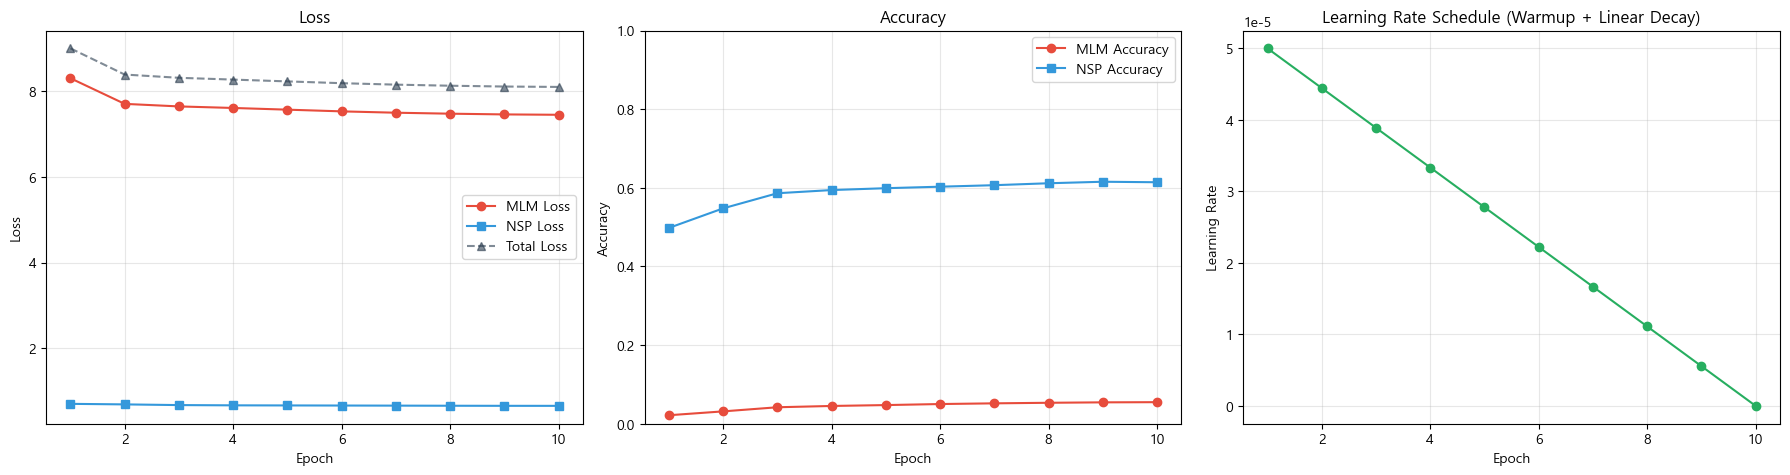


학습 결과 그래프 저장: training_results.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss 그래프
axes[0].plot(history["epoch"], history["mlm_loss"], "o-", label="MLM Loss", color="#e74c3c")
axes[0].plot(history["epoch"], history["nsp_loss"], "s-", label="NSP Loss", color="#3498db")
axes[0].plot(history["epoch"], history["total_loss"], "^--", label="Total Loss", color="#2c3e50", alpha=0.6)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy 그래프
axes[1].plot(history["epoch"], history["mlm_acc"], "o-", label="MLM Accuracy", color="#e74c3c")
axes[1].plot(history["epoch"], history["nsp_acc"], "s-", label="NSP Accuracy", color="#3498db")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

# 3. Learning Rate 그래프
axes[2].plot(history["epoch"], history["lr"], "o-", color="#27ae60")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule (Warmup + Linear Decay)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n학습 결과 그래프 저장: training_results.png")


## 11. 학습된 모델 테스트

실제로 마스킹된 토큰을 모델이 잘 예측하는지 확인.

In [33]:
model.eval()

# 테스트 배치 1개 가져오기
test_batch = next(iter(dataloader))
test_batch = {k: v.to(device) for k, v in test_batch.items()}

with torch.no_grad():
    outputs = model(
        input_ids=test_batch["input_ids"],
        attention_mask=test_batch["attention_mask"],
        token_type_ids=test_batch["token_type_ids"],
        mlm_labels=test_batch["mlm_labels"],
        nsp_label=test_batch["nsp_label"]
    )

mlm_preds = outputs["mlm_logits"].argmax(dim=-1)
nsp_preds = outputs["nsp_logits"].argmax(dim=-1)

# 첫 번째 샘플 결과 출력
sample_idx = 0
input_ids = test_batch["input_ids"][sample_idx].cpu().tolist()
mlm_labels = test_batch["mlm_labels"][sample_idx].cpu().tolist()
mlm_pred = mlm_preds[sample_idx].cpu().tolist()
nsp_label = test_batch["nsp_label"][sample_idx].item()
nsp_pred = nsp_preds[sample_idx].item()

print("=== MLM 예측 결과 ===")
print(f"{'위치':>4} | {'입력':>12} | {'정답':>12} | {'예측':>12} | {'결과':>4}")
print("-" * 60)
correct = 0
total = 0
for i, (inp, lbl, prd) in enumerate(zip(input_ids, mlm_labels, mlm_pred)):
    if lbl == -100:
        continue  # 마스킹 안 된 위치는 skip
    inp_tok = sp.id_to_piece(inp)
    lbl_tok = sp.id_to_piece(lbl)
    prd_tok = sp.id_to_piece(prd)
    is_correct = "O" if lbl == prd else "X"
    if lbl == prd:
        correct += 1
    total += 1
    print(f"{i:>4} | {inp_tok:>12} | {lbl_tok:>12} | {prd_tok:>12} | {is_correct:>4}")

print(f"\nMLM 정확도 (이 샘플): {correct}/{total} = {correct/max(1,total):.2%}")

print(f"\n=== NSP 예측 결과 ===")
print(f"정답: {'IsNext' if nsp_label == 0 else 'NotNext'}")
print(f"예측: {'IsNext' if nsp_pred == 0 else 'NotNext'}")
print(f"결과: {'정답' if nsp_label == nsp_pred else '오답'}")


=== MLM 예측 결과 ===
  위치 |           입력 |           정답 |           예측 |   결과
------------------------------------------------------------
  12 |       [MASK] |           ▁2 |            . |    X
  17 |       [MASK] |            조 |            . |    X
  30 |       [MASK] |           ▁이 |            . |    X
  33 |       [MASK] |          ▁사기 |            . |    X
  39 |       [MASK] |          ▁버그 |            . |    X
  41 |       [MASK] |           각을 |            . |    X
  55 |       [MASK] |           라이 |            . |    X
  56 |           든지 |            너 |            . |    X
  59 |       [MASK] |          ▁어린 |            . |    X
  60 |       [MASK] |          ▁선수 |            , |    X

MLM 정확도 (이 샘플): 0/10 = 0.00%

=== NSP 예측 결과 ===
정답: NotNext
예측: NotNext
결과: 정답


## 12. 프로젝트 회고

### 한 것들

이번 과제로 mini BERT를 처음부터 만들어봤다.

- vocab 8000짜리 SentencePiece BPE 토크나이저 학습
- MLM(15% 마스킹, 80-10-10 규칙)이랑 NSP(50% 확률) 데이터 직접 만들기
- BERT 모델 구조 처음부터 짜기 (Embedding → Encoder 3개 → MLM/NSP Head)
- Warmup + Linear Decay 학습률 스케줄러 적용
- 10 epoch 학습 돌리고 그래프로 결과 확인

### 어려웠던 점

- vocab_size 8000을 지키려니까 Embedding이랑 MLM decoder만 해도 2M 정도 나와서 "1M 정도"라는 과제 조건을 정확히 맞추기는 힘들었다. 결국 2~3M 정도로 타협.
- 데이터가 14MB로 작아서 MLM accuracy가 5% 정도밖에 안 나왔다. 처음엔 너무 낮은 거 아닌가 싶었는데, 8000개 중에 1개 맞추는 거니까 랜덤(0.0125%)보다는 훨씬 잘하는 거였다.
- 진짜 BERT는 수십 GB 데이터로 며칠 학습한다는데, 우리는 데이터랑 모델 둘 다 작아서 비교가 안 된다는 걸 느꼈다.

### 배운 점

- BERT랑 GPT 차이를 이제 진짜로 알게 됐다. GPT는 앞만 보고 다음 단어 예측하는데, BERT는 앞뒤 다 보고 빈칸 채우는 거. 양방향 학습이 핵심이라는 게 코드로 만들면서 확 와닿았다.
- NSP는 [CLS] 토큰 하나만 가지고 분류한다는 게 신기했다. 모든 토큰 정보가 attention으로 [CLS]에 모이는 거.
- 학습 초반에 lr을 갑자기 크게 주면 모델이 망가질 수 있어서 warmup이 필요하다는 것.
- Mixed Precision이랑 Gradient Clipping 같은 건 안 써도 동작은 하지만 학습이 더 안정적이라는 것.
- Windows에서 한국어 파일 열 때 `encoding="utf-8"` 안 붙이면 무조건 에러난다는 거... 이건 진짜 몸으로 배웠다.

### 결과 정리

| 지표 | 시작 | 끝 |
|---|---|---|
| MLM Loss | 8.3 | 7.4 |
| NSP Loss | 0.7 | 0.65 |
| MLM Accuracy | 2% | 5% |
| NSP Accuracy | 50% | 61% |

전체적으로 loss는 떨어지고 accuracy는 올라갔으니까 학습은 제대로 된 것 같다. 작은 모델이랑 작은 데이터로 한 거 치고는 만족스러운 결과.